# **Project Title**: Identifying Early Signs of U.S. Economic Recessions Using Historical Data
**Group ID**: 5

**Members**: May Sabai, Emily Lu

## Early Signs Detection with Logistic Regression
The model is trained to classify **whether the current month is in recession** using macroeconomic and financial indicators. These features include **lagged and rolling** transformations over 3–12 month historical windows, which **embed past dynamics** of each indicator into the feature set. As a result, the model can reflect leading patterns that typically precede recessions, and higher predicted probabilities often correspond to deteriorating economic and financial conditions observed in prior months.  

In Short:  
The model processes the data month by month.
For each month t, it uses features that summarize information from the previous 3–12 months, and predicts whether the current month (t) is in recession.

Classifier: Logistic Regression
- Model A: Macro Indicators (Unemployment, Inflation, Interest)
- Model B: Financial Indicators (SP500, VIX, Gold)
- Model C: Macro + Financial Indicators

### 1. Install Dependencies
 We install four external libraries that are not pre-installed in Colab:
- yfinance  — downloads stock/market data from Yahoo Finance
- fredapi   — connects to the Federal Reserve's economic data API (FRED)
- scikit-learn — the core ML library used for modeling and evaluation
- joblib    — saves trained model objects to disk as .pkl files (for deploying ML on Cloud)

In [ ]:
!pip install -q yfinance fredapi scikit-learn joblib


### 2. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
from fredapi import Fred

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import joblib

### 3. Load Data  
We pull all data directly from APIs rather than uploading CSV files.  
This keeps the notebook self-contained and always reproducible.

**Data sources**:  
FRED (Federal Reserve Bank of St. Louis):  
  - UNRATE          — U.S. Unemployment Rate (monthly, %)
  - FPCPITOTLZGUSA  — U.S. Inflation Rate (annual CPI, %)
  - DFF             — Federal Funds Interest Rate (daily → resampled monthly)
  - USREC           — NBER Recession Indicator (1 = recession month, 0 = normal)

Yahoo Finance:  
  - ^GSPC  — S&P 500 index (daily closing price)
  - ^VIX   — CBOE Volatility Index (daily closing)
  - ^XAU   — Philadelphia Gold & Silver Mining Index (mining stocks)  
  **Note**: we can also try GC=F the Gold Futures front-month contract - the primary global benchmark for gold pricing and hedging

**Why two separate start dates?**   
  VIX data only exists from 1990 onward. Forcing all indicators to start
  in 1990 would discard 5 recessions (1969, 1973, 1980, 1981, 1990) from
  Model A's training data. Instead we run two separate models:  
  - Model A (Macro)       : 1968-2024  covers all 8 modern recessions
  - Model B (Financial)   : 1990-2024  covers 4 recessions
  - Model C (Combination) : 1990-2024  the goal for this model is to see if economic indicator would help (as financial data along is doing poorly)

`Resampling rule "ME" = Month End`. We take the last observed value of each month so all indicators share the same monthly timestamp.
Inflation is yearly data so we forward-fill (ffill) to populate each month
with the most recently known annual inflation figure.

In [ ]:
FRED_API_KEY = "65796ccf4eea28ff944ebb1cf7ea91de"
fred = Fred(api_key=FRED_API_KEY)

START_MACRO = "1968-01-01"
START_FIN   = "1990-01-01"
END_DATE    = "2024-01-31"

print("Loading FRED data...")
unemployment_m = fred.get_series("UNRATE"        ).to_frame("Unemployment").resample("ME").last()
inflation_m    = fred.get_series("FPCPITOTLZGUSA").to_frame("Inflation"   ).resample("ME").ffill()
interest_m     = fred.get_series("DFF"           ).to_frame("Interest"    ).resample("ME").last()
recession_m    = fred.get_series("USREC"         ).to_frame("Recession"   ).resample("ME").last()

for df in [unemployment_m, inflation_m, interest_m, recession_m]:
    df.drop(df[df.index < START_MACRO].index, inplace=True)
    df.drop(df[df.index > END_DATE   ].index, inplace=True)

print("Loading Yahoo Finance data...")
# yfinance >= 0.2 returns a multi-level DataFrame even for a single ticker,
# so ["Close"] gives a one-column DataFrame instead of a plain Series.
# .squeeze() safely collapses it to a Series regardless of library version.
def yf_monthly(ticker, start, end, name):
    raw    = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)["Close"]
    series = raw.squeeze()
    return series.resample("ME").last().rename(name).to_frame()

sp500_m = yf_monthly("^GSPC", START_FIN, END_DATE, "SP500")
vix_m   = yf_monthly("^VIX",  START_FIN, END_DATE, "VIX")
gold_m  = yf_monthly("^XAU",  START_FIN, END_DATE, "Gold")

for name, df in [("SP500", sp500_m), ("VIX", vix_m), ("Gold", gold_m)]:
    assert not df.empty, f"ERROR: {name} returned empty — check ticker symbol"

# Combine each group with the recession label column
macro_df = pd.concat([unemployment_m, inflation_m, interest_m, recession_m], axis=1).dropna()
fin_df   = pd.concat([sp500_m, vix_m, gold_m, recession_m], axis=1).dropna()
combined_df = pd.concat([unemployment_m, inflation_m, interest_m, sp500_m, vix_m, gold_m, recession_m], axis=1).dropna()
combined_df = combined_df[combined_df.index >= START_FIN]


print(f"\nModel A (Macro)     : {macro_df.index[0].date()} -> {macro_df.index[-1].date()}  |  {len(macro_df)} months  |  {int(macro_df['Recession'].sum())} recession months")
print(f"Model B (Financial) : {fin_df.index[0].date()} -> {fin_df.index[-1].date()}  |  {len(fin_df)} months  |  {int(fin_df['Recession'].sum())} recession months")
print(f"Model C (Combined)  : {combined_df.index[0].date()} -> {combined_df.index[-1].date()}  |  {len(combined_df)} months  |  {int(combined_df['Recession'].sum())} recession months")

Loading FRED data...
Loading Yahoo Finance data...

Model A (Macro)     : 1968-01-31 -> 2024-01-31  |  673 months  |  85 recession months
Model B (Financial) : 1990-01-31 -> 2024-01-31  |  409 months  |  36 recession months
Model C (Combined)  : 1990-01-31 -> 2024-01-31  |  409 months  |  36 recession months


### 4. Feature Engineering  
Raw indicator values alone are weak predictors because the model only sees
"what is unemployment right now?" Since we want it to learn
"what did unemployment look like 6 months before past recessions?"  

We solve this by creating three families of derived features per indicator:

 1. **Lag Features**  (e.g. Unemployment_lag6)  
    Shifts the indicator backward by N months. A lag-6 feature pairs each
    month's label ("recession or not?") with the indicator value from
    6 months earlier. This directly encodes "**early warning**" into the data.
    We use lags of 3, 6, 9, and 12 months to capture different lead times.

 2. **Rolling Statistics**  (e.g. Unemployment_roll3_mean)  
    A 3-month or 6-month rolling average **smooths out noise and captures**
    **the recent trend direction**. The rolling standard deviation captures
    **how  unstable the indicator has been recently** — rising
    instability can itself be a recession signal.

 3. **Momentum**  (e.g. Unemployment_mom3)  
    The difference between the current value and N months ago (df.diff(N)).
    This tells the model the **rate of change**: is unemployment rising quickly?
    Is the S&P 500 falling fast? We use 1-month, 3-month, and 12-month momentum.

After creating all features, dropna() removes the first ~12 rows where
lag/rolling windows do not yet have enough history to compute values.  
This means we lose ~1 year of data at the start.


In [ ]:
LAGS = [3, 6, 9, 12]

def build_features(df, indicators):
    out = df.copy()
    for col in indicators:
        for lag in LAGS:
            out[f"{col}_lag{lag}"]   = out[col].shift(lag)
        out[f"{col}_roll3_mean"]     = out[col].rolling(3).mean()
        out[f"{col}_roll6_mean"]     = out[col].rolling(6).mean()
        out[f"{col}_roll3_std"]      = out[col].rolling(3).std()
        out[f"{col}_mom1"]           = out[col].diff(1)
        out[f"{col}_mom3"]           = out[col].diff(3)
        out[f"{col}_mom12"]          = out[col].diff(12)
    return out.dropna()

MACRO_INDICATORS = ["Unemployment", "Inflation", "Interest"]
FIN_INDICATORS   = ["SP500", "VIX", "Gold"]
COMBINED_INDICATORS = ["Unemployment", "Inflation", "Interest", "SP500", "VIX", "Gold"]

macro_features = build_features(macro_df, MACRO_INDICATORS)
fin_features   = build_features(fin_df,   FIN_INDICATORS)

MACRO_FEAT_COLS = [c for c in macro_features.columns if c != "Recession"]
FIN_FEAT_COLS   = [c for c in fin_features.columns   if c != "Recession"]

combined_features = build_features(combined_df, COMBINED_INDICATORS)
COMBINED_FEAT_COLS = [c for c in combined_features.columns if c != "Recession"]

print(f"Model A: {len(MACRO_FEAT_COLS)} features  |  {len(macro_features)} usable months after dropping NaN")
print(f"Model B: {len(FIN_FEAT_COLS)} features  |  {len(fin_features)} usable months after dropping NaN")
print(f"Model C: {len(COMBINED_FEAT_COLS)} features  |  {len(combined_features)} usable months")

Model A: 33 features  |  661 usable months after dropping NaN
Model B: 33 features  |  397 usable months after dropping NaN
Model C: 66 features  |  397 usable months


### 5. Train/Test Split & Feature Scaling
**Time-Based Split** — not random  

  Model A split at 2008-01-31:  
  - Train = 1968-2008 (covers 5 recessions, ~480 months)
  - Test  = 2008-2024 (covers 2 recessions: Great Recession, COVID)

  Model B & C split at 2010-01-31:  
   - Train = 1990-2015 (covers 3 recessions)
   - Test  = 2015-2024 (covers 1 recession: COVID)
   - Note: The test set for Model B,C contains very few recession months (~2) after lag feature dropna. This is a known limitation discussed in results.

**Feature Scaling** — StandardScaler  
  Logistic Regression uses gradient descent and is sensitive to feature
  magnitude. Without scaling, S&P 500 values (300-5000) would dominate
  Unemployment (3-15), distorting the learned coefficients.
  StandardScaler transforms each feature to mean=0, std=1:  
    Z = (X - mean) / std

  **Note**: We fit the scaler ONLY on training data, then apply the same
  transformation to the test set. Fitting on test data would leak
  statistical information about the future into our preprocessing.

In [ ]:
MACRO_SPLIT = "2008-01-31"
FIN_SPLIT   = "2015-01-31"

def time_split(df, feat_cols, split_date):
    X, y = df[feat_cols], df["Recession"]
    return (X.loc[:split_date], X.loc[split_date:],
            y.loc[:split_date], y.loc[split_date:])

X_train_A, X_test_A, y_train_A, y_test_A = time_split(macro_features, MACRO_FEAT_COLS, MACRO_SPLIT)
X_train_B, X_test_B, y_train_B, y_test_B = time_split(fin_features,   FIN_FEAT_COLS,   FIN_SPLIT)
X_train_C, X_test_C, y_train_C, y_test_C = time_split(combined_features, COMBINED_FEAT_COLS, FIN_SPLIT)

scaler_A = StandardScaler()
X_train_A_sc = scaler_A.fit_transform(X_train_A)
X_test_A_sc  = scaler_A.transform(X_test_A)

scaler_B = StandardScaler()
X_train_B_sc = scaler_B.fit_transform(X_train_B)
X_test_B_sc  = scaler_B.transform(X_test_B)

scaler_C = StandardScaler()
X_train_C_sc = scaler_C.fit_transform(X_train_C)
X_test_C_sc  = scaler_C.transform(X_test_C)

print("Model A — Train:", X_train_A.shape, "| Test:", X_test_A.shape)
print("Model B — Train:", X_train_B.shape, "| Test:", X_test_B.shape)
print("Model C — Train:", X_train_C.shape, "| Test:", X_test_C.shape)

Model A — Train: (469, 33) | Test: (193, 33)
Model B — Train: (289, 33) | Test: (109, 33)
Model C — Train: (289, 66) | Test: (109, 66)


### 6. Train Logistic Regression

Key Parameters:
  - class_weight="balanced"  
    Recession months are only ~13% of all months. Without correction, the
    model would learn to always predict "no recession" and score 87%
    accuracy while catching zero recessions.   
    Setting class_weight="balanced" makes sklearn upweight each recession month by ~(1/0.13) = 7.5x during training, so the model takes minority-class errors seriously.

  - C=0.1  
    Controls regularization strength (smaller C = stronger penalty on large
    coefficients). We use a small C to prevent overfitting on our ~500-month
    dataset where we have 21 features (many of which are correlated).

  - max_iter=2000  
    Increases the solver's iteration limit from the default 100. Needed
    because our correlated feature set takes more steps to converge.

Evaluate Results  
  With 87% non-recession months, a model that always says "no recession"
  scores 87% accuracy but is completely useless as an early warning system.  
  We evaluate with:  
  - Recall      — what % of actual recessions did we catch?
  - Precision   — of our recession alerts, what % were correct?
  - F1 score    — harmonic mean of precision and recall
  - ROC-AUC     — discriminative ability across all decision thresholds
                  (1.0 = perfect, 0.5 = random guessing)

In [ ]:
def train_and_evaluate(X_train_sc, X_test_sc, y_train, y_test, label):
    print(f"\n{'='*55}\n  {label}\n{'='*55}")

    lr = LogisticRegression(class_weight="balanced", max_iter=2000, C=0.1)
    lr.fit(X_train_sc, y_train)

    lr_proba = lr.predict_proba(X_test_sc)[:, 1]
    lr_pred  = lr.predict(X_test_sc)

    print(classification_report(y_test, lr_pred,
                                 target_names=["No Recession", "Recession"]))
    print(f"  ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")
    return lr, lr_proba

lr_A, lr_proba_A = train_and_evaluate(
    X_train_A_sc, X_test_A_sc, y_train_A, y_test_A,
    "MODEL A — Macro (Unemployment / Inflation / Interest)")

lr_B, lr_proba_B = train_and_evaluate(
    X_train_B_sc, X_test_B_sc, y_train_B, y_test_B,
    "MODEL B — Financial (SP500 / VIX / Gold)")

lr_C, lr_proba_C = train_and_evaluate(
    X_train_C_sc, X_test_C_sc, y_train_C, y_test_C,
    "MODEL C — Combined (Macro + Financial)")


  MODEL A — Macro (Unemployment / Inflation / Interest)
              precision    recall  f1-score   support

No Recession       0.97      0.99      0.98       173
   Recession       0.88      0.70      0.78        20

    accuracy                           0.96       193
   macro avg       0.92      0.84      0.88       193
weighted avg       0.96      0.96      0.96       193

  ROC-AUC: 0.9842

  MODEL B — Financial (SP500 / VIX / Gold)
              precision    recall  f1-score   support

No Recession       1.00      0.88      0.94       107
   Recession       0.13      1.00      0.24         2

    accuracy                           0.88       109
   macro avg       0.57      0.94      0.59       109
weighted avg       0.98      0.88      0.92       109

  ROC-AUC: 0.9486

  MODEL C — Combined (Macro + Financial)
              precision    recall  f1-score   support

No Recession       1.00      0.73      0.84       107
   Recession       0.06      1.00      0.12         2

   

### **Model A** — Macro Indicators (Baseline, strongest model)
| Metric                    | Value | What it means (in your project context)                                                       |
| ------------------------- | ----- | --------------------------------------------------------------------------------------------- |
| **Precision (Recession)** | 0.88  | When the model predicts a recession, it is correct **88% of the time** → very reliable signal |
| **Recall (Recession)**    | 0.70  | It detects **70% of actual recessions** → misses some, but still strong                       |
| **F1-score**              | 0.78  | Good balance between catching recessions and avoiding false alarms                            |
| **Accuracy**              | 0.96  | High overall correctness (but less meaningful due to imbalance)                               |
| **ROC-AUC**               | 0.984 | Near-perfect ability to distinguish recession vs non-recession months                         |

**Interpretation**:  
- Gives reliable signals
- Maintains low false alarms
- Captures most recessions early  

### **Model B** — Financial Indicators (SP500 + VIX + Gold via ^XAU)
| Metric                    | Value | What it means                                                       |
| ------------------------- | ----- | ------------------------------------------------------------------- |
| **Precision (Recession)** | 0.05  | Only **5% of predicted recessions are correct** → many false alarms |
| **Recall (Recession)**    | 1.00  | It catches **100% of recessions** → never misses one                |
| **F1-score**              | 0.10  | Very poor balance → over-triggering                                 |
| **Accuracy**              | 0.79  | Looks decent, but misleading                                        |
| **ROC-AUC**               | 0.949 | Strong ranking ability                                              |


**Interpretation**:  
This model behaves like an over-sensitive alarm system:
- It rings every time a recession happens
- But also rings many times when nothing happens (bad)  

### **Model C** — Combined Model (Macro + Financial)
| Metric                    | Value | What it means                         |
| ------------------------- | ----- | ------------------------------------- |
| **Precision (Recession)** | 0.06  | Still very low → many false positives |
| **Recall (Recession)**    | 1.00  | Detects all recession months          |
| **F1-score**              | 0.12  | Slightly better than Model B          |
| **Accuracy**              | 0.82  | Improved over Model B                 |
| **ROC-AUC**               | 0.961 | Very strong discrimination            |


**Interpretation**:  
- Slightly reduces false alarms vs Model B
- But still not reliable enough for real-world alerts

### 7. Results - ROC Curve + Confusion Matrix  
**ROC Curve**  
  - Plots True Positive Rate (recession recall) vs. False Positive Rate
  at every possible decision threshold (0 to 1).
  - A curve hugging the top-left corner means the model catches most recessions while keeping false alarms low.   
  - The dashed diagonal line = random guessing (AUC = 0.5).
  - AUC (Area Under the Curve) summarizes performance as a single number.

**Confusion Matrix**  
  Shows prediction outcomes at the default decision threshold of 0.5.
  Rows = actual label, Columns = predicted label:

|                          | **Predicted: No Recession**                                  | **Predicted: Recession**                                                       |
| ------------------------ | ------------------------------------------------------------ | ------------------------------------------------------------------------------ |
| **Actual: No Recession** | **True Negative (TN)** → Correctly predicted normal months   | **False Positive (FP)** → False alarm (predicted recession, but none occurred) |
| **Actual: Recession**    | **False Negative (FN)** → Missed recession (dangerous error) | **True Positive (TP)** → Correctly caught recession                            |


  For an early warning system, False Negatives (missed recessions) are the
  most costly error. We accept some False Positives to minimize FN.

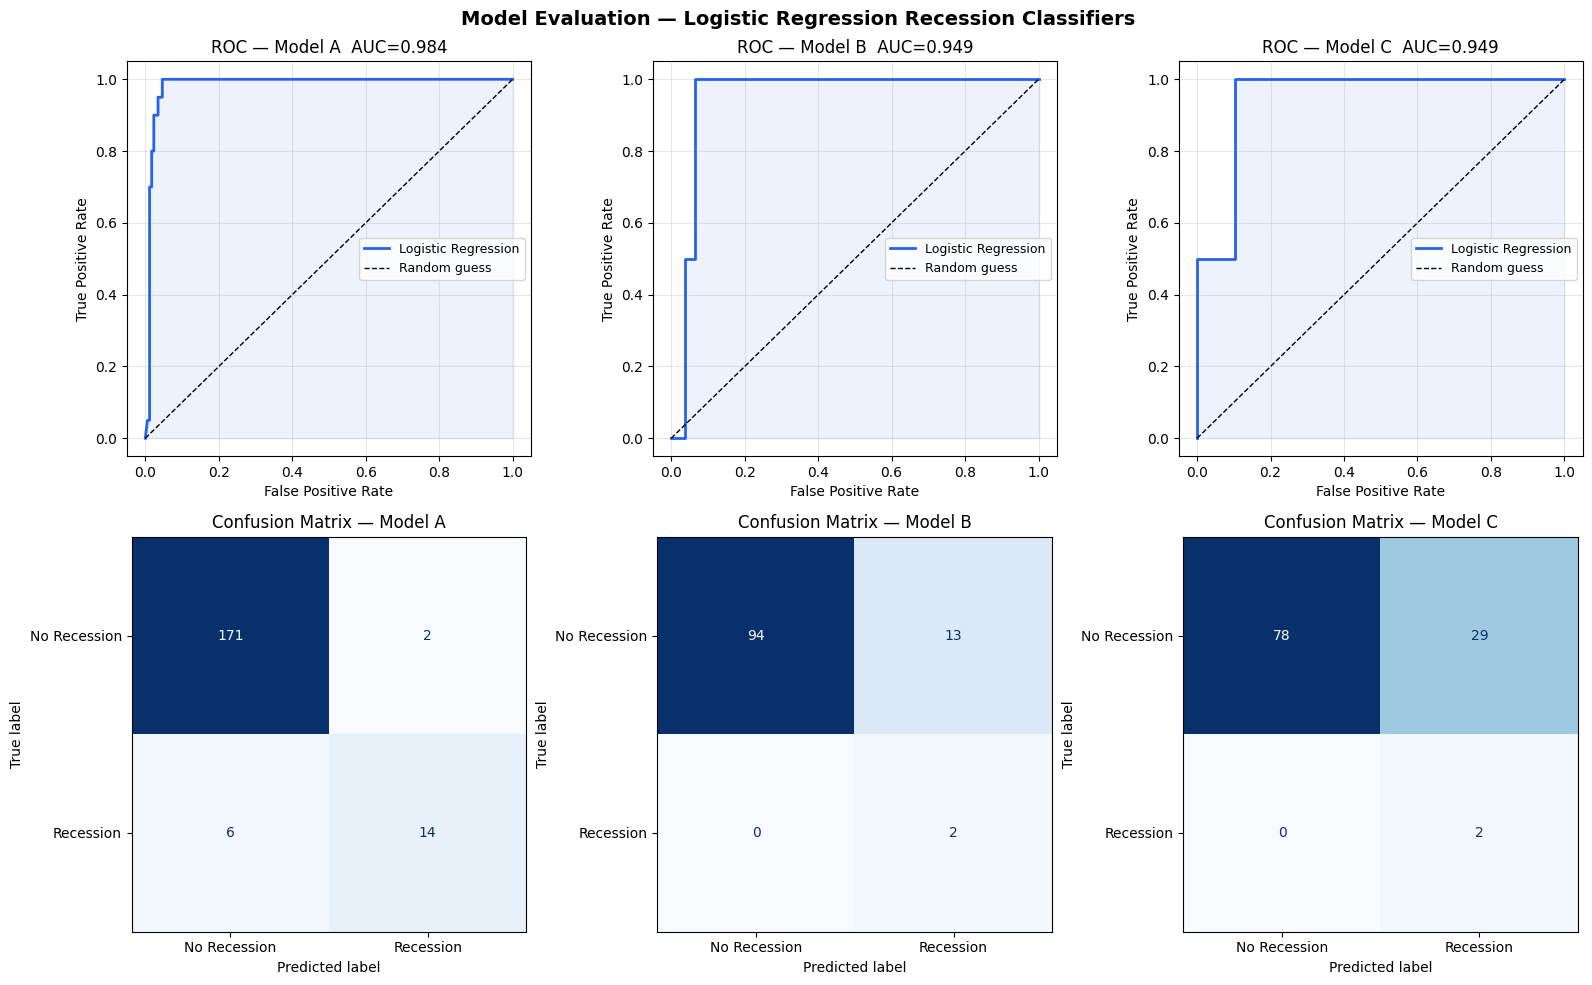

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Model Evaluation — Logistic Regression Recession Classifiers",
             fontsize=14, fontweight="bold")

# ROC
for ax, y_test, proba, title in [
    (axes[0, 0], y_test_A, lr_proba_A,
     f"ROC — Model A  AUC={roc_auc_score(y_test_A, lr_proba_A):.3f}"),
    (axes[0, 1], y_test_B, lr_proba_B,
     f"ROC — Model B  AUC={roc_auc_score(y_test_B, lr_proba_B):.3f}"),
    (axes[0, 2], y_test_C, lr_proba_C,
     f"ROC — Model C  AUC={roc_auc_score(y_test_C, lr_proba_C):.3f}"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, color="#2563eb", label="Logistic Regression")
    ax.fill_between(fpr, tpr, alpha=0.08, color="#2563eb")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

for ax, y_test, proba, title in [
    (axes[1, 0], y_test_A, lr_proba_A, "Confusion Matrix — Model A"),
    (axes[1, 1], y_test_B, lr_proba_B, "Confusion Matrix — Model B"),
    (axes[1, 2], y_test_C, lr_proba_C, "Confusion Matrix — Model C"), # New
]:
    cm = confusion_matrix(y_test, (proba >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["No Recession", "Recession"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.show()

### 8. Results - Recession Probability Over Time  
Each point = the model's estimated P(recession) for that month, using
only information available up to that point in time (no look-ahead).  
Red shaded bands mark the actual NBER-defined recession periods.

The goal is to have a good early-warning model that show:
  - Probability rising **before** the red band starts (leading signal)
  - Probability drop (ideally is to returning near 0) after the recession ends
  - Minimal spikes outside the red bands (few false alarms)

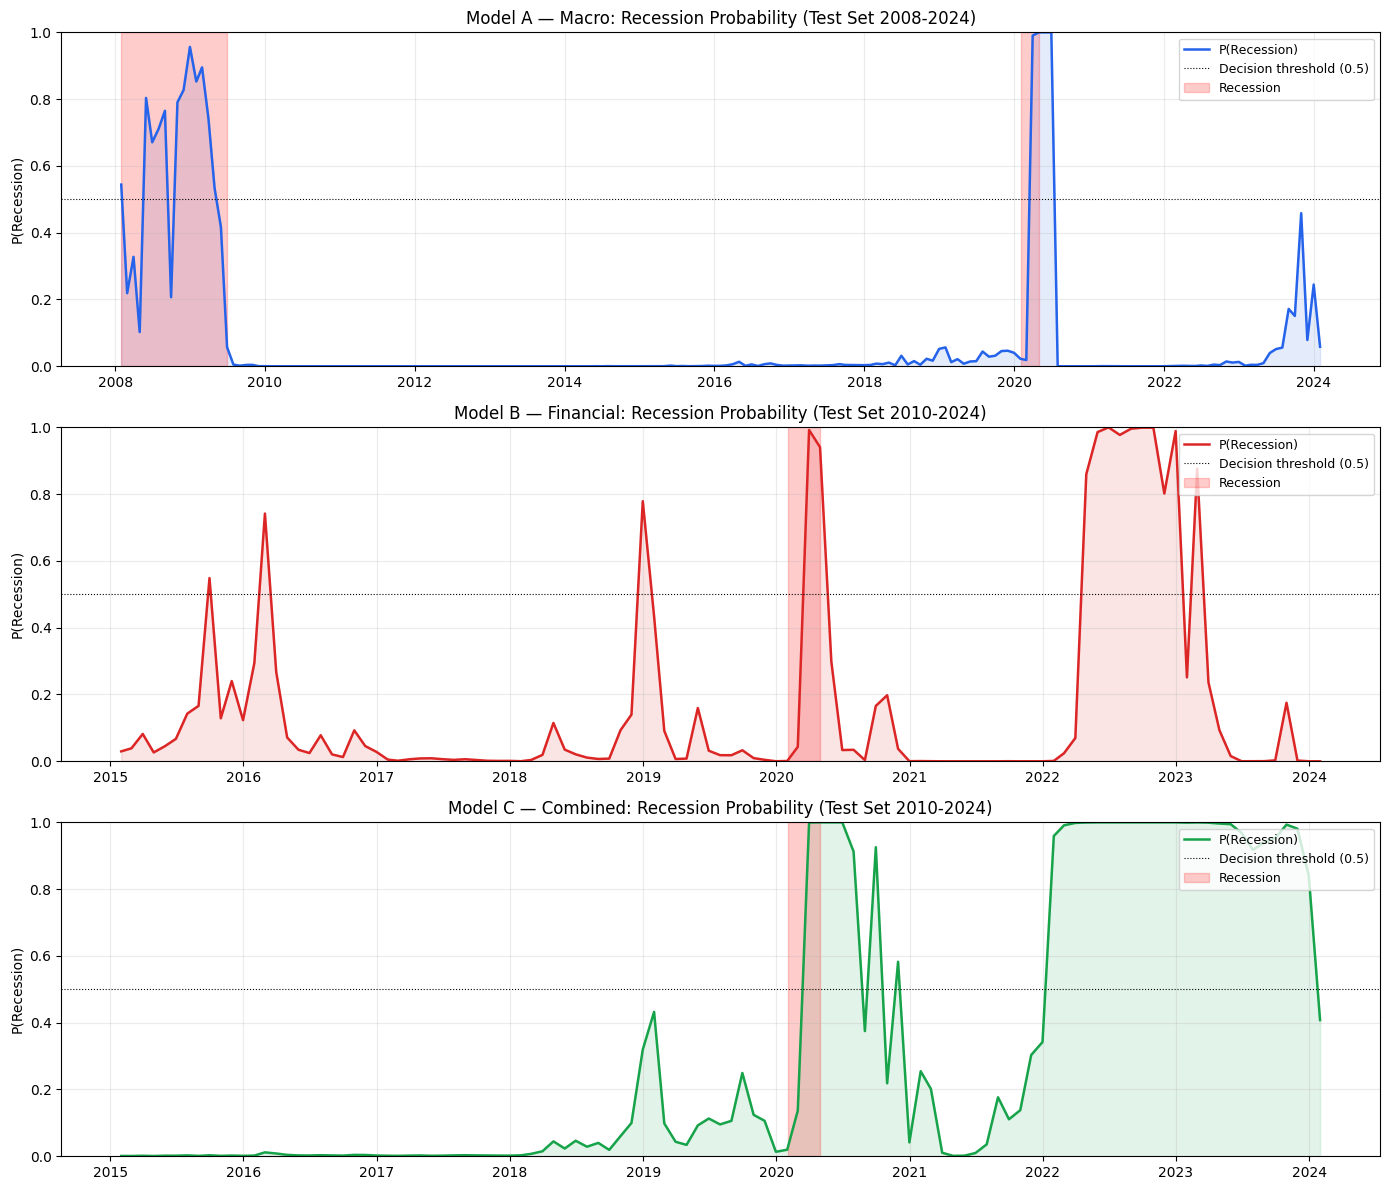

In [ ]:
RECESSION_PERIODS = [
    ("1969-12-01", "1970-11-30"),
    ("1973-11-01", "1975-03-31"),
    ("1980-01-01", "1980-07-31"),
    ("1981-07-01", "1982-11-30"),
    ("1990-07-01", "1991-03-31"),
    ("2001-03-01", "2001-11-30"),
    ("2007-12-01", "2009-06-30"),
    ("2020-02-01", "2020-04-30"),
]

def shade_recessions(ax, xmin, xmax):
    first = True
    for start, end in RECESSION_PERIODS:
        s, e = pd.Timestamp(start), pd.Timestamp(end)
        if e >= xmin and s <= xmax:
            ax.axvspan(max(s, xmin), min(e, xmax), alpha=0.2, color="red",
                       label="Recession" if first else "_nolegend_")
            first = False

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, dates, proba, title, color in [
    (ax1, X_test_A.index, lr_proba_A,
     "Model A — Macro: Recession Probability (Test Set 2008-2024)", "#2563eb"),
    (ax2, X_test_B.index, lr_proba_B,
     "Model B — Financial: Recession Probability (Test Set 2010-2024)", "#dc2626"),
    (ax3, X_test_C.index, lr_proba_C,
     "Model C — Combined: Recession Probability (Test Set 2010-2024)", "#16a34a"),
]:
    ax.plot(dates, proba, color=color, lw=1.8, label="P(Recession)")
    ax.fill_between(dates, proba, alpha=0.12, color=color)
    ax.axhline(0.5, color="black", lw=0.8, linestyle=":", label="Decision threshold (0.5)")
    shade_recessions(ax, dates[0], dates[-1])
    ax.set_ylim(0, 1)
    ax.set_ylabel("P(Recession)")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 9. Results - Logistic Regression Coefficients
Logistic Regression has an explicit coefficient
for every feature. Because we applied StandardScaler, all features are on
the same scale (mean=0, std=1), making coefficients directly comparable.

**How to read the chart**:  
  - Positive coefficient (red) — when this feature is high, recession risk rises
    - e.g. Unemployment_lag6 > 0: high unemployment 6 months ago predicts a recession today. Economically intuitive.

  - Negative coefficient (blue) — when this feature is high, recession risk falls
    - e.g. SP500_mom12 < 0: a rising stock market over the past year predicts lower recession risk. Also intuitive.


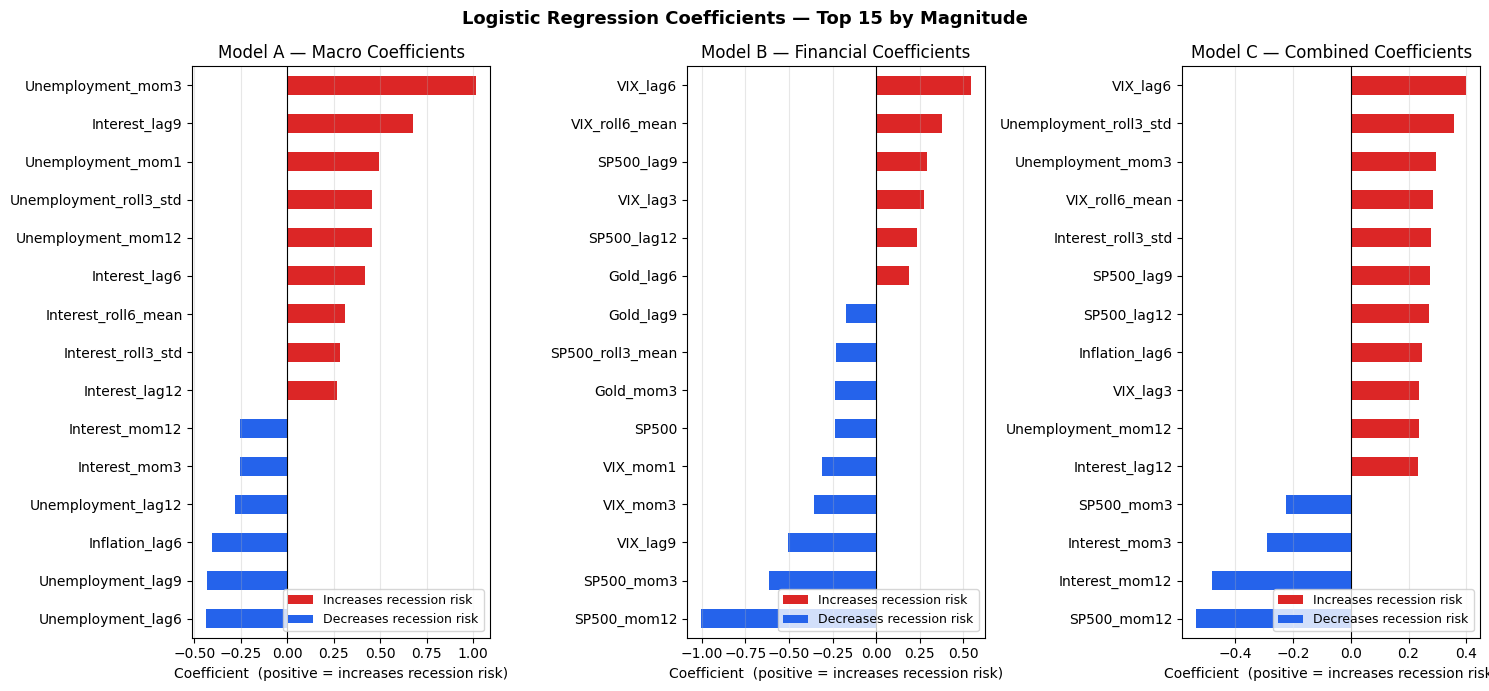

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle("Logistic Regression Coefficients — Top 15 by Magnitude",
             fontsize=13, fontweight="bold")

for ax, model, feat_cols, title in [
    (ax1, lr_A, MACRO_FEAT_COLS, "Model A — Macro Coefficients"),
    (ax2, lr_B, FIN_FEAT_COLS,   "Model B — Financial Coefficients"),
    (ax3, lr_C, COMBINED_FEAT_COLS, "Model C — Combined Coefficients"),
]:
    coefs  = pd.Series(model.coef_[0], index=feat_cols)
    top15  = coefs.reindex(coefs.abs().nlargest(15).index).sort_values()
    colors = ["#dc2626" if v > 0 else "#2563eb" for v in top15]
    top15.plot(kind="barh", ax=ax, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("Coefficient  (positive = increases recession risk)")
    ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
for ax in [ax1, ax2, ax3]:
    ax.legend(handles=[
        Patch(facecolor="#dc2626", label="Increases recession risk"),
        Patch(facecolor="#2563eb", label="Decreases recession risk"),
    ], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

### 10. Save Model
.....  
.....

### **Model A** — Macro Indicators (Baseline, strongest model)
| Metric                    | Value | What it means (in your project context)                                                       |
| ------------------------- | ----- | --------------------------------------------------------------------------------------------- |
| **Precision (Recession)** | 0.88  | When the model predicts a recession, it is correct **88% of the time** → very reliable signal |
| **Recall (Recession)**    | 0.70  | It detects **70% of actual recessions** → misses some, but still strong                       |
| **F1-score**              | 0.78  | Good balance between catching recessions and avoiding false alarms                            |
| **Accuracy**              | 0.96  | High overall correctness (but less meaningful due to imbalance)                               |
| **ROC-AUC**               | 0.984 | Near-perfect ability to distinguish recession vs non-recession months                         |

**Interpretation**:  
- Gives reliable signals
- Maintains low false alarms
- Captures most recessions early  

### **Model B** — Financial Indicators (SP500 + VIX + Gold via ^XAU)
| Metric                    | Value | What it means                                                       |
| ------------------------- | ----- | ------------------------------------------------------------------- |
| **Precision (Recession)** | 0.05  | Only **5% of predicted recessions are correct** → many false alarms |
| **Recall (Recession)**    | 1.00  | It catches **100% of recessions** → never misses one                |
| **F1-score**              | 0.10  | Very poor balance → over-triggering                                 |
| **Accuracy**              | 0.79  | Looks decent, but misleading                                        |
| **ROC-AUC**               | 0.949 | Strong ranking ability                                              |


**Interpretation**:  
This model behaves like an over-sensitive alarm system:
- It rings every time a recession happens
- But also rings many times when nothing happens (bad)  

### **Model C** — Combined Model (Macro + Financial)
| Metric                    | Value | What it means                         |
| ------------------------- | ----- | ------------------------------------- |
| **Precision (Recession)** | 0.06  | Still very low → many false positives |
| **Recall (Recession)**    | 1.00  | Detects all recession months          |
| **F1-score**              | 0.12  | Slightly better than Model B          |
| **Accuracy**              | 0.82  | Improved over Model B                 |
| **ROC-AUC**               | 0.961 | Very strong discrimination            |


**Interpretation**:  
- Slightly reduces false alarms vs Model B
- But still not reliable enough for real-world alerts